# Agent Scaffold Comparison on CORE-Bench (Hard)

This notebook creates a stacked bar chart comparing Claude Code vs smolagents CodeAgent across multiple Claude models.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.image as mpimg
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import colorsys
import seaborn as sns
import os
from pathlib import Path

from matplotlib.ticker import PercentFormatter, MultipleLocator
from matplotlib.patches import Patch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, HPacker, AnchoredOffsetbox

In [17]:
# Setup paths
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
quantitative_dir = project_root / 'quantitative'
assets_dir = quantitative_dir / 'assets'
plots_dir = notebook_dir / 'results' / 'plots'

# Create plots directory if it doesn't exist
plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Assets directory: {assets_dir}")
print(f"Plots directory: {plots_dir}")

Assets directory: /Users/peterkirgis/Documents/hal-paper-analysis/quantitative/assets
Plots directory: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results/plots


In [18]:
# Configure matplotlib with Inter font (HAL style)
font_path = assets_dir / "InterVariable.ttf"
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = 'Inter'

mpl.rcParams.update({
    "font.family": "Inter" if font_path.exists() else "sans-serif",
    "font.weight": 400,
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 12,
    "hatch.linewidth": 0.8,
})

sns.set_theme(style="white", rc={"axes.grid": False})

## Sample Data

Define sample accuracy data for each model and scaffold combination.

In [19]:
# Sample data: accuracy for each model/scaffold combination
# Models: Claude Opus 4.5, Claude Sonnet 4.5, Claude Opus 4.1, Claude Sonnet 4
# Scaffolds: Claude Code, CORE-Agent (using HF smolagents)

# For Claude Opus 4.5 + Claude Code, we have two accuracies:
# - automatic_accuracy: 0.78 (from automatic grading)
# - manual_accuracy: 0.93 (from manual grading)

data = {
    'model': [
        'Claude Opus 4.5', 'Claude Opus 4.5',
        'Claude Sonnet 4.5', 'Claude Sonnet 4.5',
        'Claude Opus 4.1', 'Claude Opus 4.1',
        'Claude Sonnet 4', 'Claude Sonnet 4'
    ],
    'scaffold': [
        'CORE-Agent (using HF smolagents)', 'Claude Code',
        'CORE-Agent (using HF smolagents)', 'Claude Code',
        'CORE-Agent (using HF smolagents)', 'Claude Code',
        'CORE-Agent (using HF smolagents)', 'Claude Code'
    ],
    'accuracy': [
        0.42, 0.78,  # Opus 4.5 (automatic grading for Claude Code)
        0.44, 0.62,  # Sonnet 4.5
        0.51, 0.42,  # Opus 4.1
        0.33, 0.47   # Sonnet 4
    ],
    # Manual accuracy only applies to Claude Opus 4.5 + Claude Code
    'manual_accuracy': [
        None, 0.95,  # Opus 4.5 (manual grading for Claude Code)
        None, None,  # Sonnet 4.5
        None, None,  # Opus 4.1
        None, None   # Sonnet 4
    ]
}

df = pd.DataFrame(data)
df

,model,scaffold,accuracy,manual_accuracy
0,Claude Opus 4.5,CORE-Agent (using HF smolagents),0.42,NaN
1,Claude Opus 4.5,Claude Code,0.78,0.95
2,Claude Sonnet 4.5,CORE-Agent (using HF smolagents),0.44,NaN
3,Claude Sonnet 4.5,Claude Code,0.62,NaN
4,Claude Opus 4.1,CORE-Agent (using HF smolagents),0.51,NaN
5,Claude Opus 4.1,Claude Code,0.42,NaN
6,Claude Sonnet 4,CORE-Agent (using HF smolagents),0.33,NaN
7,Claude Sonnet 4,Claude Code,0.47,NaN


## Plot Configuration

In [20]:
# Color scheme for scaffolds - smolagents black, Claude Code tan
SCAFFOLD_COLORS = {
    'Claude Code': '#D4A27F',        # Anthropic brand color (tan)
    'smolagents CodeAgent': '#2C2C2C' # Black/dark grey for smolagents
}

# Logo paths
LOGO_PATHS = {
    'Anthropic': str(assets_dir / 'anthropic_grey.png'),
    'Claude': str(assets_dir / 'claude.png'),  # New Claude logo for legend
    'HAL': str(assets_dir / 'HAL.png'),
    'smolagents': str(assets_dir / 'smolagents.png'),
}

# Footer logo paths
FOOTER_LOGOS = [
    str(assets_dir / 'HAL.png'),
    str(quantitative_dir / 'hal-frontend' / 'static' / 'pli.png'),
    str(quantitative_dir / 'hal-frontend' / 'static' / 'princeton.png'),
]

# Plot text
TITLE = "Opus 4.5 with Claude Code scores 95% on CORE-Bench Hard"
SUBTITLE = "Compared to our previous best scaffold for evaluating CORE-Bench, Claude Code doubles the accuracy of Opus 4.5."
FOOTER_NOTE = "Since the benchmark was close to saturation, we manually scored all tasks solved by Opus 4.5 with Claude Code \nto spot errors in the benchmark auto-grading. Due to edge cases in the automatic grading, manual validation \nincreased the agent’s accuracy by 17 percentage points (shaded bar)."

## Create the Grouped Bar Chart

## Figure 2: Stacked Bar Chart (Visualizing Differences)

This version uses stacked horizontal bars to clearly show the improvement from Claude Code over smolagents. The difference is displayed directly on the bar.

In [21]:
def create_grouped_bar_comparison(df, save_plot=True):
    """
    Create a grouped bar chart comparing scaffolds across models.
    For bars with manual_accuracy, show a stacked bar with hatching to 
    differentiate automatic vs manual grading.
    """
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle, Patch
    
    # Get unique models
    models = df['model'].unique()
    n_models = len(models)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Bar positioning
    x = np.arange(n_models)
    width = 0.35
    spacing = 0.02
    
    # Get accuracies for each scaffold per model
    claude_code_data = []
    smolagents_data = []
    
    for m in models:
        cc_row = df[(df['model'] == m) & (df['scaffold'] == 'Claude Code')]
        sm_row = df[(df['model'] == m) & (df['scaffold'] == 'CORE-Agent (using HF smolagents)')]
        
        claude_code_data.append({
            'accuracy': cc_row['accuracy'].values[0],
            'manual_accuracy': cc_row['manual_accuracy'].values[0] if pd.notna(cc_row['manual_accuracy'].values[0]) else None
        })
        smolagents_data.append({
            'accuracy': sm_row['accuracy'].values[0],
            'manual_accuracy': None
        })
    
    # Draw bars for each model
    for i, model in enumerate(models):
        cc_data = claude_code_data[i]
        sm_data = smolagents_data[i]
        
        # Claude Code bar (left)
        cc_x = x[i] - (width/2 + spacing/2)
        
        if cc_data['manual_accuracy'] is not None:
            # Special case: stacked bar with automatic (solid) and manual increment (hatched)
            auto_acc = cc_data['accuracy']
            manual_acc = cc_data['manual_accuracy']
            manual_increment = manual_acc - auto_acc
            
            # Automatic grading portion (solid)
            ax.bar(
                cc_x, 
                auto_acc, 
                width,
                color=SCAFFOLD_COLORS['Claude Code'],
                edgecolor='black',
                linewidth=0.8
            )
            
            # Manual grading increment (hatched)
            ax.bar(
                cc_x, 
                manual_increment, 
                width,
                bottom=auto_acc,
                color=SCAFFOLD_COLORS['Claude Code'],
                edgecolor='black',
                linewidth=0.8,
                hatch='///',
                alpha=0.85
            )
            
            # Label showing automatic accuracy on the solid portion
            ax.text(
                cc_x,
                auto_acc / 2,
                f'{auto_acc:.0%}',
                ha='center',
                va='center',
                fontsize=18,
                fontweight='bold',
                color='white'
            )
            
            # Label showing increment on hatched portion with "(manual grading)" on two lines below
            ax.text(
                cc_x,
                auto_acc + manual_increment / 2,
                f'+{manual_increment:.0%}\n(manual\ngrading)',
                ha='center',
                va='center',
                fontsize=14,
                fontweight='bold',
                color='white',
                linespacing=0.9
            )
            
            # Total (manual) accuracy label above bar
            ax.text(
                cc_x,
                manual_acc + 0.015,
                f'{manual_acc:.0%}',
                ha='center',
                va='bottom',
                fontsize=18,
                fontweight='bold',
                color=SCAFFOLD_COLORS['Claude Code']
            )
        else:
            # Regular bar for Claude Code
            ax.bar(
                cc_x, 
                cc_data['accuracy'], 
                width,
                color=SCAFFOLD_COLORS['Claude Code'],
                edgecolor='black',
                linewidth=0.8
            )
            # Label for Claude Code
            ax.text(
                cc_x,
                cc_data['accuracy'] + 0.015,
                f'{cc_data["accuracy"]:.0%}',
                ha='center',
                va='bottom',
                fontsize=18,
                fontweight='bold',
                color=SCAFFOLD_COLORS['Claude Code']
            )
        
        # smolagents bar (right)
        sm_x = x[i] + (width/2 + spacing/2)
        ax.bar(
            sm_x, 
            sm_data['accuracy'], 
            width,
            color=SCAFFOLD_COLORS['smolagents CodeAgent'],
            edgecolor='black',
            linewidth=0.8
        )
        # Label for smolagents
        ax.text(
            sm_x,
            sm_data['accuracy'] + 0.015,
            f'{sm_data["accuracy"]:.0%}',
            ha='center',
            va='bottom',
            fontsize=20,
            fontweight='bold',
            color=SCAFFOLD_COLORS['smolagents CodeAgent']
        )
    
    # Styling
    ax.set_xticks(x)
    ax.set_xticklabels([''] * n_models)  # Clear default labels
    ax.set_ylabel('Accuracy (%)', fontsize=22, fontweight='bold')
    
    # Set y-axis limit
    max_acc = max(
        max([d['accuracy'] for d in smolagents_data]),
        max([d['manual_accuracy'] if d['manual_accuracy'] else d['accuracy'] for d in claude_code_data])
    )
    ax.set_ylim(0, max_acc + 0.12)
    ax.set_xlim(-0.6, n_models - 0.4)
    ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    
    # Add model labels with Anthropic logo below x-axis
    anthropic_logo_path = LOGO_PATHS.get('Anthropic')
    
    for i, model in enumerate(models):
        # Add Anthropic logo below the axis
        if anthropic_logo_path and os.path.exists(anthropic_logo_path):
            img = mpimg.imread(anthropic_logo_path)
            zoom = 24 / img.shape[0]
            ax.add_artist(AnnotationBbox(
                OffsetImage(img, zoom=zoom, resample=True),
                (x[i], -0.04),
                xycoords=('data', 'axes fraction'),
                frameon=False,
                box_alignment=(0.5, 1)
            ))
        
        # Add model name below logo
        ax.text(
            x[i], -0.12,
            model,
            ha='center',
            va='top',
            fontsize=18,
            transform=ax.get_xaxis_transform()
        )
    
    # Clean up spines
    sns.despine(ax=ax, top=True, right=True)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    
    ax.tick_params(axis='y', which='major', color='black', width=1, length=4, labelsize=16)
    ax.tick_params(axis='x', which='major', length=0)
    
    # Custom legend with logos - scaffold legend and grading legend SIDE BY SIDE
    claude_logo_path = LOGO_PATHS.get('Claude')
    smolagents_logo_path = LOGO_PATHS.get('smolagents')
    
    # Legend positioning - further right and down
    legend_y = 0.88  # moved down
    scaffold_legend_x = 0.35  # moved right
    grading_legend_x = 0.8  # second legend to the right of first
    legend_spacing = 0.07
    logo_size = 24
    
    # === SCAFFOLD LEGEND (left) ===
    # Claude Code entry
    if claude_logo_path and os.path.exists(claude_logo_path):
        img = mpimg.imread(claude_logo_path)
        zoom = logo_size / img.shape[0]
        ax.add_artist(AnnotationBbox(
            OffsetImage(img, zoom=zoom, resample=True),
            (scaffold_legend_x, legend_y),
            xycoords='axes fraction',
            frameon=False,
            box_alignment=(0, 0.5)
        ))
    
    ax.add_patch(Rectangle(
        (scaffold_legend_x + 0.04, legend_y - 0.015), 0.025, 0.03,
        transform=ax.transAxes,
        facecolor=SCAFFOLD_COLORS['Claude Code'],
        edgecolor='black',
        linewidth=0.5,
        clip_on=False
    ))
    ax.text(scaffold_legend_x + 0.075, legend_y, 'Claude Code', 
            transform=ax.transAxes, fontsize=18, va='center', fontweight='medium')
    
    # smolagents entry
    if smolagents_logo_path and os.path.exists(smolagents_logo_path):
        img = mpimg.imread(smolagents_logo_path)
        zoom = logo_size / img.shape[0]
        ax.add_artist(AnnotationBbox(
            OffsetImage(img, zoom=zoom, resample=True),
            (scaffold_legend_x, legend_y - legend_spacing),
            xycoords='axes fraction',
            frameon=False,
            box_alignment=(0, 0.5)
        ))
    
    ax.add_patch(Rectangle(
        (scaffold_legend_x + 0.04, legend_y - legend_spacing - 0.015), 0.025, 0.03,
        transform=ax.transAxes,
        facecolor=SCAFFOLD_COLORS['smolagents CodeAgent'],
        edgecolor='black',
        linewidth=0.5,
        clip_on=False
    ))
    ax.text(scaffold_legend_x + 0.075, legend_y - legend_spacing, 'CORE-Agent (using HF smolagents)', 
            transform=ax.transAxes, fontsize=18, va='center', fontweight='medium')
    
    # === GRADING LEGEND (right) ===
    # Automatic grading (solid)
    ax.add_patch(Rectangle(
        (grading_legend_x, legend_y - 0.015), 0.025, 0.03,
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='black',
        linewidth=0.5,
        clip_on=False
    ))
    ax.text(grading_legend_x + 0.035, legend_y, 'Automatic grading', 
            transform=ax.transAxes, fontsize=16, va='center', color='.4')
    
    # Manual grading (hatched)
    ax.add_patch(Rectangle(
        (grading_legend_x, legend_y - legend_spacing - 0.015), 0.025, 0.03,
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='black',
        linewidth=0.5,
        hatch='///',
        clip_on=False
    ))
    ax.text(grading_legend_x + 0.035, legend_y - legend_spacing, 'Manual grading', 
            transform=ax.transAxes, fontsize=16, va='center', color='.4')
    
    # Title and subtitle
    fig.text(0.05, 0.97, TITLE, ha='left', va='top',
             fontsize=24, fontweight='bold')
    fig.text(0.05, 0.93, SUBTITLE, ha='left', va='top',
             fontsize=18, color='.35')
    
    # Footer
    fig.subplots_adjust(bottom=0.25, top=0.88)
    
    ax_note = fig.add_axes([0.05, 0.02, 0.6, 0.10])
    ax_note.axis('off')
    ax_note.text(0, 0, FOOTER_NOTE, ha='left', va='bottom',
                 fontsize=14, color='.35', wrap=True, linespacing=1.25)
    
    # Footer logos
    icons = []
    for p in FOOTER_LOGOS:
        if os.path.exists(p):
            img = mpimg.imread(p)
            zoom = 34 / img.shape[0]
            icons.append(OffsetImage(img, zoom=zoom, resample=True))
    
    if icons:
        fig.add_artist(AnchoredOffsetbox(
            loc='lower right',
            child=HPacker(children=icons, align='center', pad=0, sep=5),
            frameon=False, pad=0,
            bbox_to_anchor=(0.95, 0.02),
            bbox_transform=fig.transFigure, borderpad=0
        ))
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.25)
    
    plt.show()
    
    if save_plot:
        output_path = plots_dir / 'scaffold_comparison_grouped.pdf'
        fig.savefig(output_path, bbox_inches='tight', dpi=300)
        print(f"Saved plot: {output_path}")
        
        output_path_png = plots_dir / 'scaffold_comparison_grouped.png'
        fig.savefig(output_path_png, bbox_inches='tight', dpi=300)
        print(f"Saved plot: {output_path_png}")
    
    return fig, ax

/var/folders/dc/2_03ytv916s79g_kt7ch3ck00000gn/T/ipykernel_22358/4237295167.py:321: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


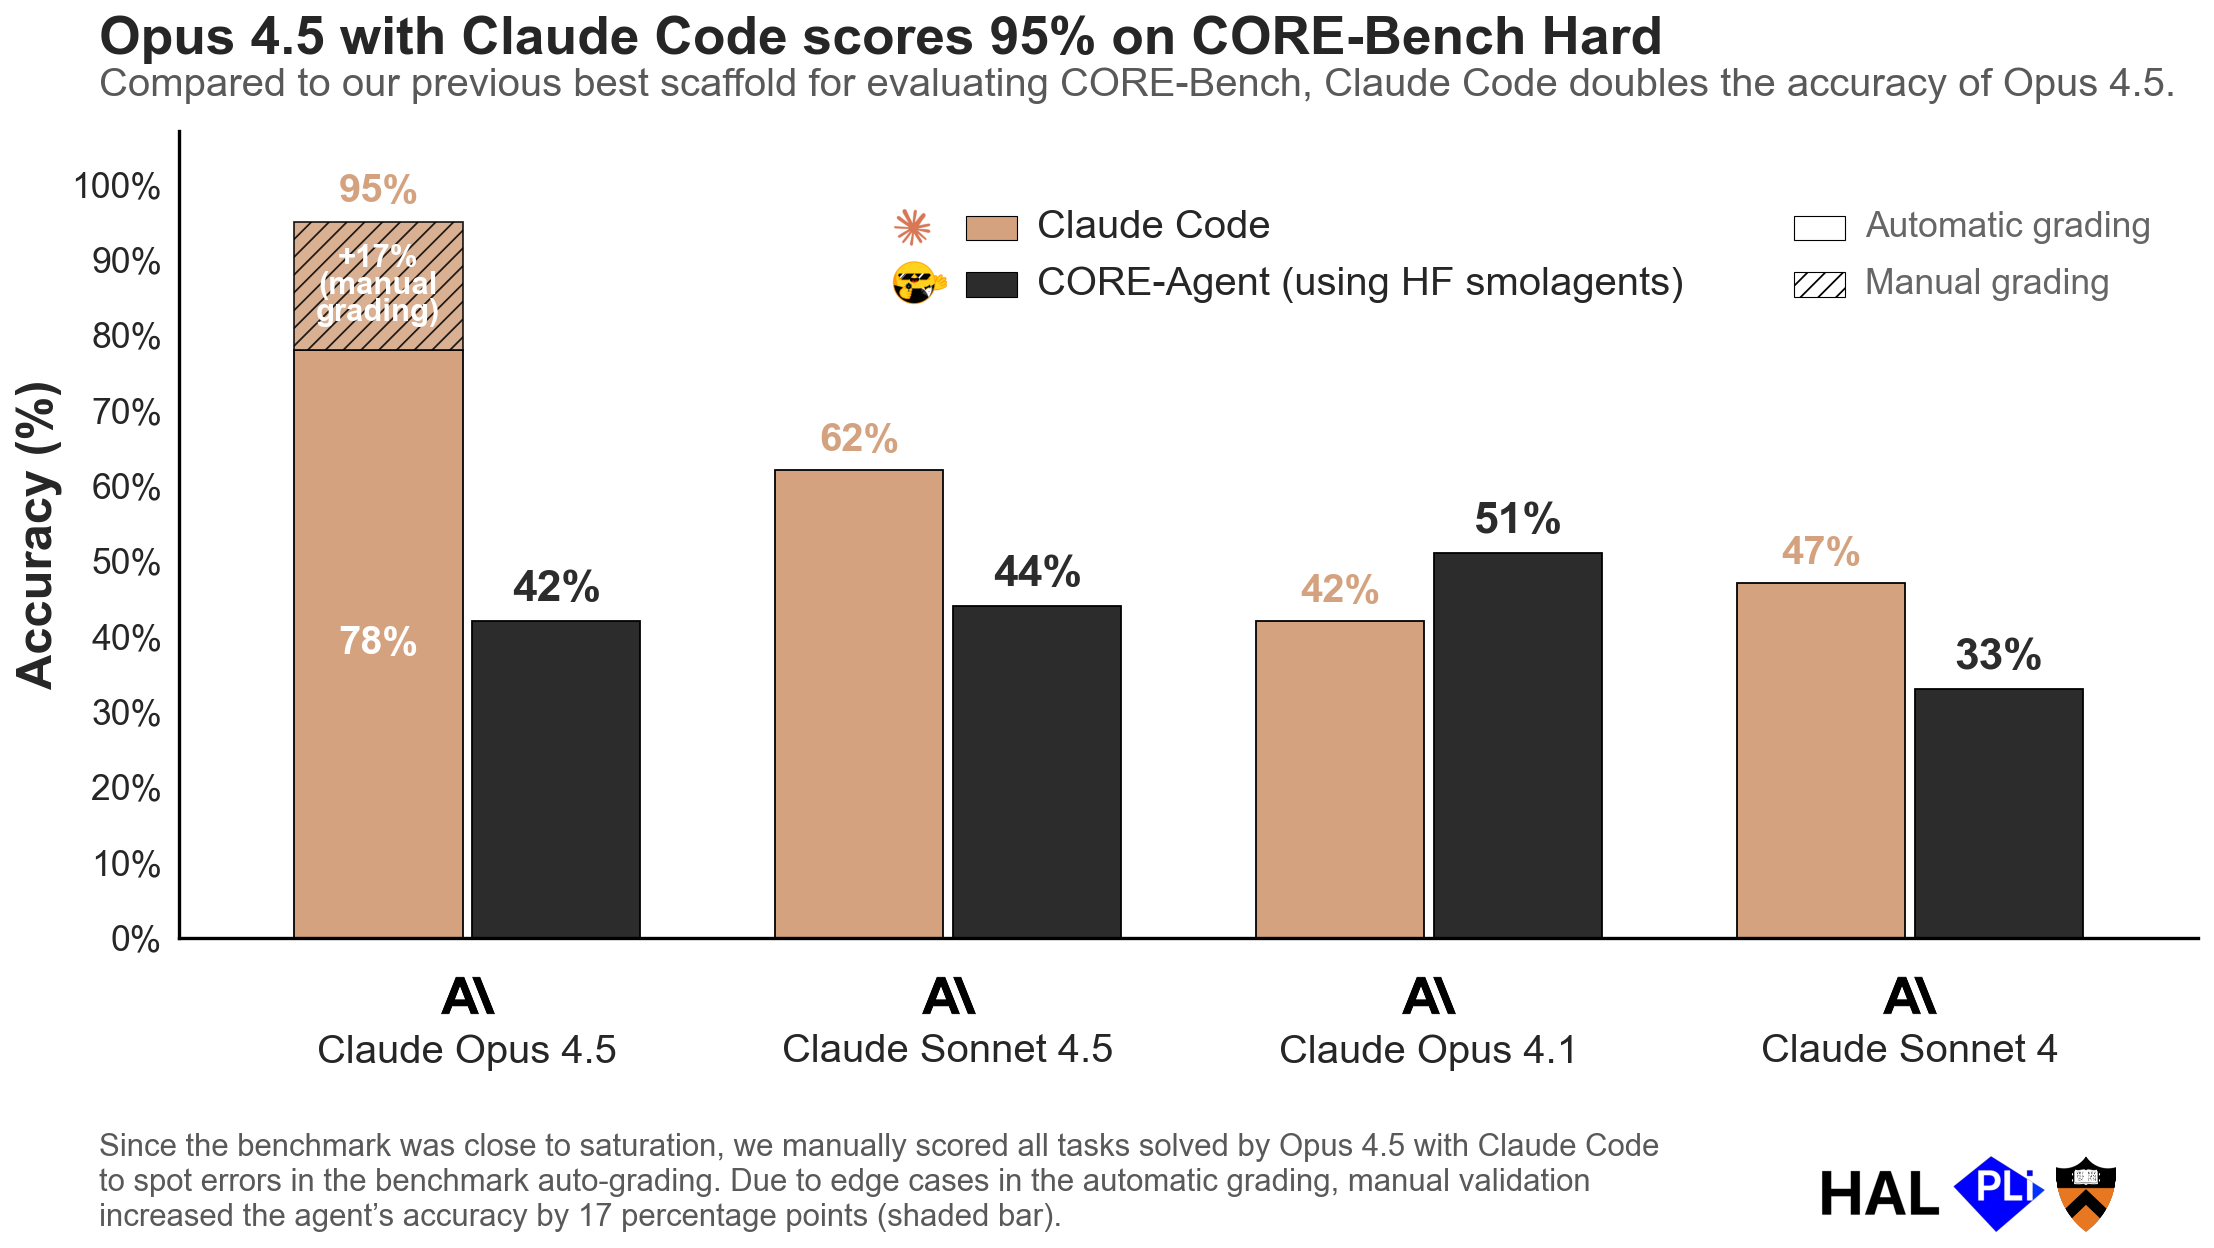

Saved plot: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results/plots/scaffold_comparison_grouped.pdf
Saved plot: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results/plots/scaffold_comparison_grouped.png


In [22]:
# Create grouped bar chart with automatic/manual grading distinction
fig2, ax2 = create_grouped_bar_comparison(df, save_plot=True)

## Data Summary

In [23]:
# Pivot table for easy comparison
pivot_df = df.pivot(index='model', columns='scaffold', values='accuracy')
pivot_df['Difference'] = pivot_df['Claude Code'] - pivot_df['smolagents CodeAgent']
pivot_df['% Improvement'] = (pivot_df['Difference'] / pivot_df['smolagents CodeAgent'] * 100).round(1)
pivot_df

KeyError: 'smolagents CodeAgent'

In [24]:
# Summary statistics
print("Summary Statistics:")
print(f"Average Claude Code accuracy: {df[df['scaffold'] == 'Claude Code']['accuracy'].mean():.1%}")
print(f"Average smolagents accuracy: {df[df['scaffold'] == 'smolagents CodeAgent']['accuracy'].mean():.1%}")
print(f"Average improvement with Claude Code: {pivot_df['% Improvement'].mean():.1f}%")

Summary Statistics:
Average Claude Code accuracy: 57.2%
Average smolagents accuracy: nan%


KeyError: '% Improvement'

## Qualitative Analysis: Why Opus 4.5 Solves CORE-Bench

Last week, we found Claude Opus 4.5 solves CORE-Bench. How? **Opus 4.5 solves CORE-Bench because it creatively resolves dependency conflicts, bypasses environmental barriers via nuanced benchmark editing, and follows instructions with high fidelity.** Opus 4.1 and Sonnet 4, when given the same powerful scaffold, fail because they resort to simulated data when running into conflicts and provide answers using heuristics rather than precise data. We also observe Opus 4.5 more accurately representing its actions in its summary workflow, displaying stronger agentic alignment.

In [25]:
# Qualitative comparison data across 10 capsules
qualitative_data = {
    'Capsule': [
        '1394704', '2345790', '3262218', '3418007', '3449234',
        '3639589', '4252248', '5136217', '7716865', '8807709'
    ],
    'Opus 4.1': [
        'Environmental barriers → simulated data + misrepresentation. Env failures blocked Rmd; computed on synthetic incidence; summary overstated completion.',
        'Environmental barriers → heuristic aggregation. Disk blocked Rmd; used trial-level mean (not across participants) and wrong units.',
        'Heuristic shortcut + instruction miss. Used caption total (57) vs methods subset (45) after failing to render.',
        'Environmental barriers → heuristic pipeline substitution. Couldn\'t reproduce deps; ran simplified custom model (diff splits/params).',
        'Environmental barriers → misrepresentation / wrong target. Treated "error" as exception text and wrote that as the answer.',
        'Heuristic shortcut from code reading. Inferred color from wrong plot section because env wasn\'t runnable.',
        'Environmental barriers → simulated/placeholder metric. Couldn\'t run pipeline; hard-coded AUC.',
        'Environmental barriers → heuristic guess. Couldn\'t compute party; hard-coded guess; second answer came from code.',
        'Instruction-following nuance (rounding). Returned unrounded value instead of table\'s rounded value.',
        'Environmental barriers → simulated plot substitute. API/deps mismatch; answered from custom visualization.'
    ],
    'Sonnet 4': [
        'Environmental barriers → heuristic/simulated fallback. Disk/deps blocked Rmd; replaced pipeline + hard-coded epidemic curve.',
        'Environmental barriers → precision-only output. Correct values but emitted unrounded full precision.',
        'Heuristic shortcut over precise data. Computed methods=45 but deferred to manuscript narrative total (57).',
        'Heuristic substitution over precise data. Pulled metrics from tuning logs instead of requested figure outputs.',
        'Heuristic guess vs observing outputs. Guessed highest-std model without inspecting the figure.',
        'Heuristic shortcut + wrong figure. Answered from earlier plot, didn\'t verify the DM-specific figure.',
        'Environmental barriers → heuristic estimate. No outputs; wrote "typical" AUC.',
        'Environmental barriers → heuristic guess. Couldn\'t run; guessed party.',
        'Environmental barriers → heuristic approximation. Couldn\'t run WebPower; manual ANOVA-only approximation.',
        'Environmental barriers → simulated plot substitute. Couldn\'t run epidemic.py; answered from surrogate sim.'
    ],
    'Opus 4.5': [
        'Creative debugging + instruction following. Fixed deps/Pandoc + small Rmd edit; ran intended workflow; extracted ground-truth from HTML.',
        'Creative debugging + instruction following. Rendered official Rmds; extracted correct response rates; cross-checked with participant-level logic.',
        'Instruction following under constraints. Computed the methods subset directly from processed data; returned 45.',
        'Creative debugging (benchmark editing) to run. Patched code + deps to restore execution; generated outputs; extracted requested metrics.',
        'Instruction following + precise data extraction. Re-ran notebook, parsed numeric errors, inspected the rendered plot to answer.',
        'Creative debugging + precise verification. Ran script, computed maxima, and verified on the rendered figure.',
        'Creative debugging + precise data. Installed deps, fixed runtime bugs, ran end-to-end, wrote computed AUC.',
        'Creative debugging + precise outputs. Installed deps, ran scripts, generated figures, extracted computed answers.',
        'Creative debugging + instruction following. Ran official computations and returned table-consistent rounded value.',
        'Creative debugging + precise reproduction. Pinned compatible version, ran epidemic.py, used produced PNG/CSVs.'
    ]
}

qualitative_df = pd.DataFrame(qualitative_data)
qualitative_df

,Capsule,Opus 4.1,Sonnet 4,Opus 4.5
0,1394704,Environmental barriers → simulated data + misr...,Environmental barriers → heuristic/simulated f...,Creative debugging + instruction following. Fi...
1,2345790,Environmental barriers → heuristic aggregation...,Environmental barriers → precision-only output...,Creative debugging + instruction following. Re...
2,3262218,Heuristic shortcut + instruction miss. Used ca...,Heuristic shortcut over precise data. Computed...,Instruction following under constraints. Compu...
3,3418007,Environmental barriers → heuristic pipeline su...,Heuristic substitution over precise data. Pull...,Creative debugging (benchmark editing) to run....
4,3449234,Environmental barriers → misrepresentation / w...,Heuristic guess vs observing outputs. Guessed ...,Instruction following + precise data extractio...
5,3639589,Heuristic shortcut from code reading. Inferred...,Heuristic shortcut + wrong figure. Answered fr...,Creative debugging + precise verification. Ran...
6,4252248,Environmental barriers → simulated/placeholder...,Environmental barriers → heuristic estimate. N...,Creative debugging + precise data. Installed d...
7,5136217,Environmental barriers → heuristic guess. Coul...,Environmental barriers → heuristic guess. Coul...,Creative debugging + precise outputs. Installe...
8,7716865,Instruction-following nuance (rounding). Retur...,Environmental barriers → heuristic approximati...,Creative debugging + instruction following. Ra...
9,8807709,Environmental barriers → simulated plot substi...,Environmental barriers → simulated plot substi...,Creative debugging + precise reproduction. Pin...


In [36]:
# Simplified qualitative comparison - ~5 words per cell
qualitative_data_simple = {
    'Task Topic': [
        'Measuring contagious disease spread', 'Computing response rates', 'Counting methods counter-arguments', 'Twitter bot detection with ML', 'Comparing temp prediction models',
        'Analyzing plot colors', 'Drug integration research', 'Political party voting shares', 'Neurofeedback power analysis', 'Epidemic simulation'
    ],
    'Opus 4.1': [
        'Hit dependency issues and did not run script',
        'Hit dependency issues, wrote incorrect ad hoc script',
        'Misinterpreted the question',
        'Used simplified scripts with incorrect parameters',
        'Hit dependency issues, wrote oversimplified replication scripts',
        'Accidentally returned an error message as an answer',
        'Hit dependency issues, misinterpreted plot',
        'Ran out of disk space',
        'Incorrect precision in answer',
        'Hit dependency issues, incorrect custom script',
    ],
    'Sonnet 4': [
        'Hit dependency issues and resorted to hard coded values',
        'Correct values, wrong precision',
        'Used incorrect summary statistic',
        'Hit dependency issues, used incorrect metric',
        'Guessed without inspecting figure',
        'Analyzed the wrong figure',
        'Hit dependency issues, used general knowledge estimate',
        'Ran out of disk space, guessed answer',
        'Hit dependency issues, manual approximation',
        'Hit dependency issues, used incorrect simulation',
    ],
    'Opus 4.5': [
        'Fixed dependencies, ran intended workflow',
        'Rendered files, cross-checked logic',
        'Targeted correct metric',
        'Patched code and extracted metrics',
        'Re-ran notebook, inspected plot',
        'Installed a missing dependency',
        'Fixed bugs, ran end-to-end',
        'Installed key dependency',
        'Installed key dependency',
        'Found compatible version for package',
    ]
}

qualitative_df_simple = pd.DataFrame(qualitative_data_simple)
qualitative_df_simple

,Task Topic,Opus 4.1,Sonnet 4,Opus 4.5
0,Measuring contagious disease spread,Hit dependency issues and did not run script,Hit dependency issues and resorted to hard cod...,"Fixed dependencies, ran intended workflow"
1,Computing response rates,"Hit dependency issues, wrote incorrect ad hoc ...","Correct values, wrong precision","Rendered files, cross-checked logic"
2,Counting methods counter-arguments,Misinterpreted the question,Used incorrect summary statistic,Targeted correct metric
3,Twitter bot detection with ML,Used simplified scripts with incorrect parameters,"Hit dependency issues, used incorrect metric",Patched code and extracted metrics
4,Comparing temp prediction models,"Hit dependency issues, wrote oversimplified re...",Guessed without inspecting figure,"Re-ran notebook, inspected plot"
5,Analyzing plot colors,Accidentally returned an error message as an a...,Analyzed the wrong figure,Installed a missing dependency
6,Drug integration research,"Hit dependency issues, misinterpreted plot","Hit dependency issues, used general knowledge ...","Fixed bugs, ran end-to-end"
7,Political party voting shares,Ran out of disk space,"Ran out of disk space, guessed answer",Installed key dependency
8,Neurofeedback power analysis,Incorrect precision in answer,"Hit dependency issues, manual approximation",Installed key dependency
9,Epidemic simulation,"Hit dependency issues, incorrect custom script","Hit dependency issues, used incorrect simulation",Found compatible version for package


Saved: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results/plots/qualitative_comparison_table.pdf
Saved: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results/plots/qualitative_comparison_table.png


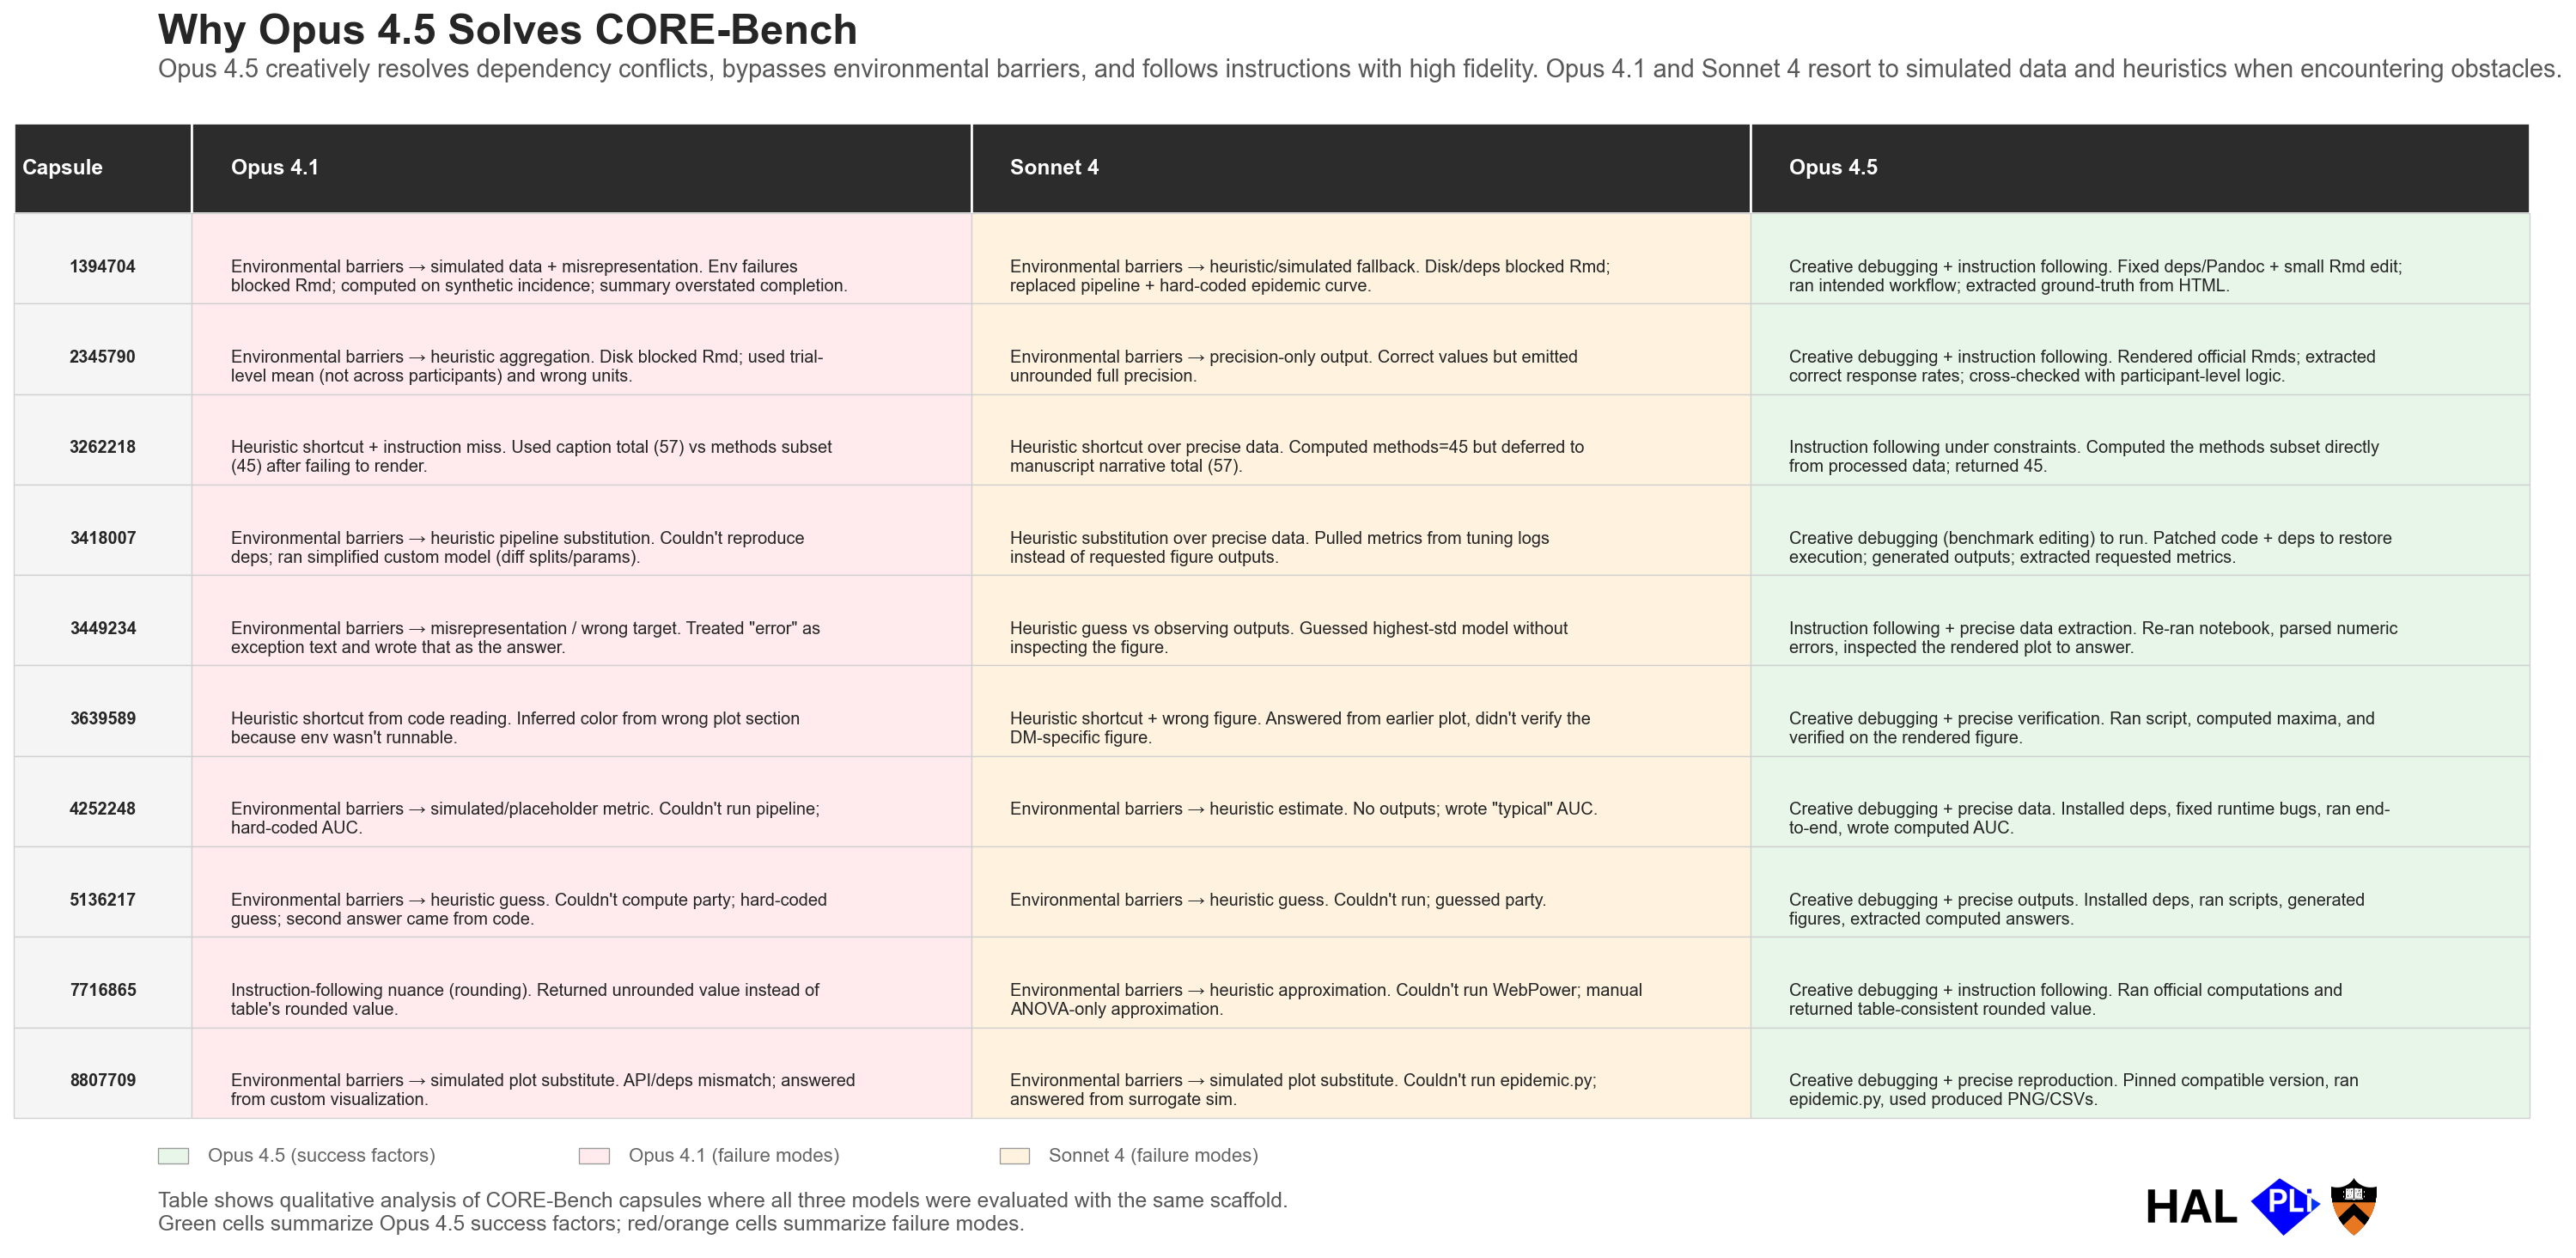

In [37]:
import os
from textwrap import fill

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnchoredOffsetbox, HPacker


def create_qualitative_table_figure(
    df,
    plots_dir,
    footer_logos=None,
    save_plot=True,
    filename_stem="qualitative_comparison_table",
    title="Why Opus 4.5 Solves CORE-Bench",
    subtitle=(
        "Opus 4.5 creatively resolves dependency conflicts, bypasses environmental barriers, and follows instructions with high fidelity. Opus 4.1 and Sonnet 4 resort to simulated data and heuristics when encountering obstacles."
    ),
    footer_note=(
        "Table shows qualitative analysis of CORE-Bench capsules where all three models were evaluated with the same scaffold.\n"
        "Green cells summarize Opus 4.5 success factors; red/orange cells summarize failure modes."
    ),
    wrap_widths=None,
    col_widths=None,
    fontsize=9,
    header_fontsize=11,
):
    """
    Matplotlib table figure with wrapped text, title/subtitle/footer, optional logos, and a color legend.

    Required columns (by default): ['Capsule', 'Opus 4.1', 'Sonnet 4', 'Opus 4.5'].
    """

    footer_logos = footer_logos or []
    wrap_widths = wrap_widths or {"Capsule": 10, 
                                  "Opus 4.1": 80, 
                                  "Sonnet 4": 80, 
                                  "Opus 4.5": 80}
    col_widths = col_widths or [0.08, 0.35, 0.35, 0.35]

    # ---- Colors (keep simple; match your thread language) ----
    header_color = "#2C2C2C"
    capsule_color = "#F5F5F5"
    opus45_color = "#E8F5E9"   # success factors
    opus41_color = "#FFEBEE"   # failure modes
    sonnet4_color = "#FFF3E0"  # failure modes

    # ---- Build wrapped table text ----
    cell_text = []
    for _, row in df.iterrows():
        wrapped_row = []
        for col in df.columns:
            text = "" if row[col] is None else str(row[col])
            wrapped_row.append(fill(text, width=wrap_widths.get(col, 44)))
        cell_text.append(wrapped_row)

    n_rows = len(df)

    # ---- Figure sizing: based on wrapped line count (more stable than n_rows * constant) ----
    def _max_lines(col_idx):
        return max((cell_text[i][col_idx].count("\n") + 1 for i in range(n_rows)), default=1)

    approx_lines = max(_max_lines(j) for j in range(len(df.columns))) if n_rows else 1
    fig_height = 3.8 + n_rows * max(0.55, 0.12 * approx_lines)  # tuned for readability
    fig, ax = plt.subplots(figsize=(18, fig_height))
    ax.axis("off")

    # ---- Table ----
    table = ax.table(
        cellText=cell_text,
        colLabels=list(df.columns),
        cellLoc="left",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)

    # Slightly increase row height, but don't blow it up (your 2.8 was often too tall)
    table.scale(1,4)

    # ---- Header styling ----
    for j, _ in enumerate(df.columns):
        cell = table[(0, j)]
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", fontweight="bold", fontsize=header_fontsize, ha="left", va="center")
        cell.set_edgecolor("white")
        cell.set_linewidth(1.2)
        cell.PAD = 0.05

    # ---- Data styling ----
    for i in range(n_rows):
        for j, col in enumerate(df.columns):
            cell = table[(i + 1, j)]
            cell.set_edgecolor("#D0D0D0")
            cell.set_linewidth(0.6)
            cell.PAD = 0.05

            if col == "Capsule":
                cell.set_facecolor(capsule_color)
                cell.set_text_props(fontweight="bold", ha="center", va="top")
            elif col == "Opus 4.5":
                cell.set_facecolor(opus45_color)
                cell.set_text_props(ha="left", va="top")
            elif col == "Opus 4.1":
                cell.set_facecolor(opus41_color)
                cell.set_text_props(ha="left", va="top")
            elif col == "Sonnet 4":
                cell.set_facecolor(sonnet4_color)
                cell.set_text_props(ha="left", va="top")
            else:
                cell.set_facecolor("#FFFFFF" if i % 2 == 0 else "#FAFAFA")
                cell.set_text_props(ha="left", va="top")

    # ---- Title / subtitle ----
    fig.text(0.05, 0.975, title, ha="left", va="top", fontsize=22, fontweight="bold")
    fig.text(0.05, 0.94, subtitle, ha="left", va="top", fontsize=13, color=".35", linespacing=1.25)

    # ---- Footer note ----
    fig.text(0.05, 0.02, footer_note, ha="left", va="bottom", fontsize=11, color=".35", linespacing=1.2)

    # ---- Legend (use your thread language) ----
    legend_items = [
        (opus45_color, "Opus 4.5 (success factors)"),
        (opus41_color, "Opus 4.1 (failure modes)"),
        (sonnet4_color, "Sonnet 4 (failure modes)"),
    ]
    legend_y = 0.075
    legend_x = 0.05
    box_size = 0.012
    spacing = 0.17

    for k, (color, label) in enumerate(legend_items):
        x = legend_x + k * spacing
        fig.patches.append(
            plt.Rectangle(
                (x, legend_y),
                box_size,
                box_size,
                facecolor=color,
                edgecolor="#9A9A9A",
                linewidth=0.6,
                transform=fig.transFigure,
                clip_on=False,
            )
        )
        fig.text(x + box_size + 0.008, legend_y + box_size / 2, label, ha="left", va="center", fontsize=10, color=".4")

    # ---- Footer logos (optional) ----
    icons = []
    for p in footer_logos:
        if p and os.path.exists(p):
            img = mpimg.imread(p)
            zoom = 30 / img.shape[0]
            icons.append(OffsetImage(img, zoom=zoom, resample=True))

    if icons:
        fig.add_artist(
            AnchoredOffsetbox(
                loc="lower right",
                child=HPacker(children=icons, align="center", pad=0, sep=6),
                frameon=False,
                bbox_to_anchor=(0.95, 0.012),
                bbox_transform=fig.transFigure,
                borderpad=0,
            )
        )

    # Layout: keep space for title/footer/legend
    plt.subplots_adjust(top=0.88, bottom=0.12, left=0.05, right=0.95)

    if save_plot:
        os.makedirs(plots_dir, exist_ok=True)
        pdf_path = os.path.join(plots_dir, f"{filename_stem}.pdf")
        png_path = os.path.join(plots_dir, f"{filename_stem}.png")
        fig.savefig(pdf_path, bbox_inches="tight", dpi=300, facecolor="white")
        fig.savefig(png_path, bbox_inches="tight", dpi=300, facecolor="white")
        print(f"Saved: {pdf_path}")
        print(f"Saved: {png_path}")

    plt.show()
    return fig


# Example usage:
fig = create_qualitative_table_figure(
    qualitative_df,
    plots_dir=plots_dir,
    footer_logos=FOOTER_LOGOS,
    save_plot=True
)

Saved: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results/plots/qualitative_comparison_table.pdf
Saved: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results/plots/qualitative_comparison_table.png


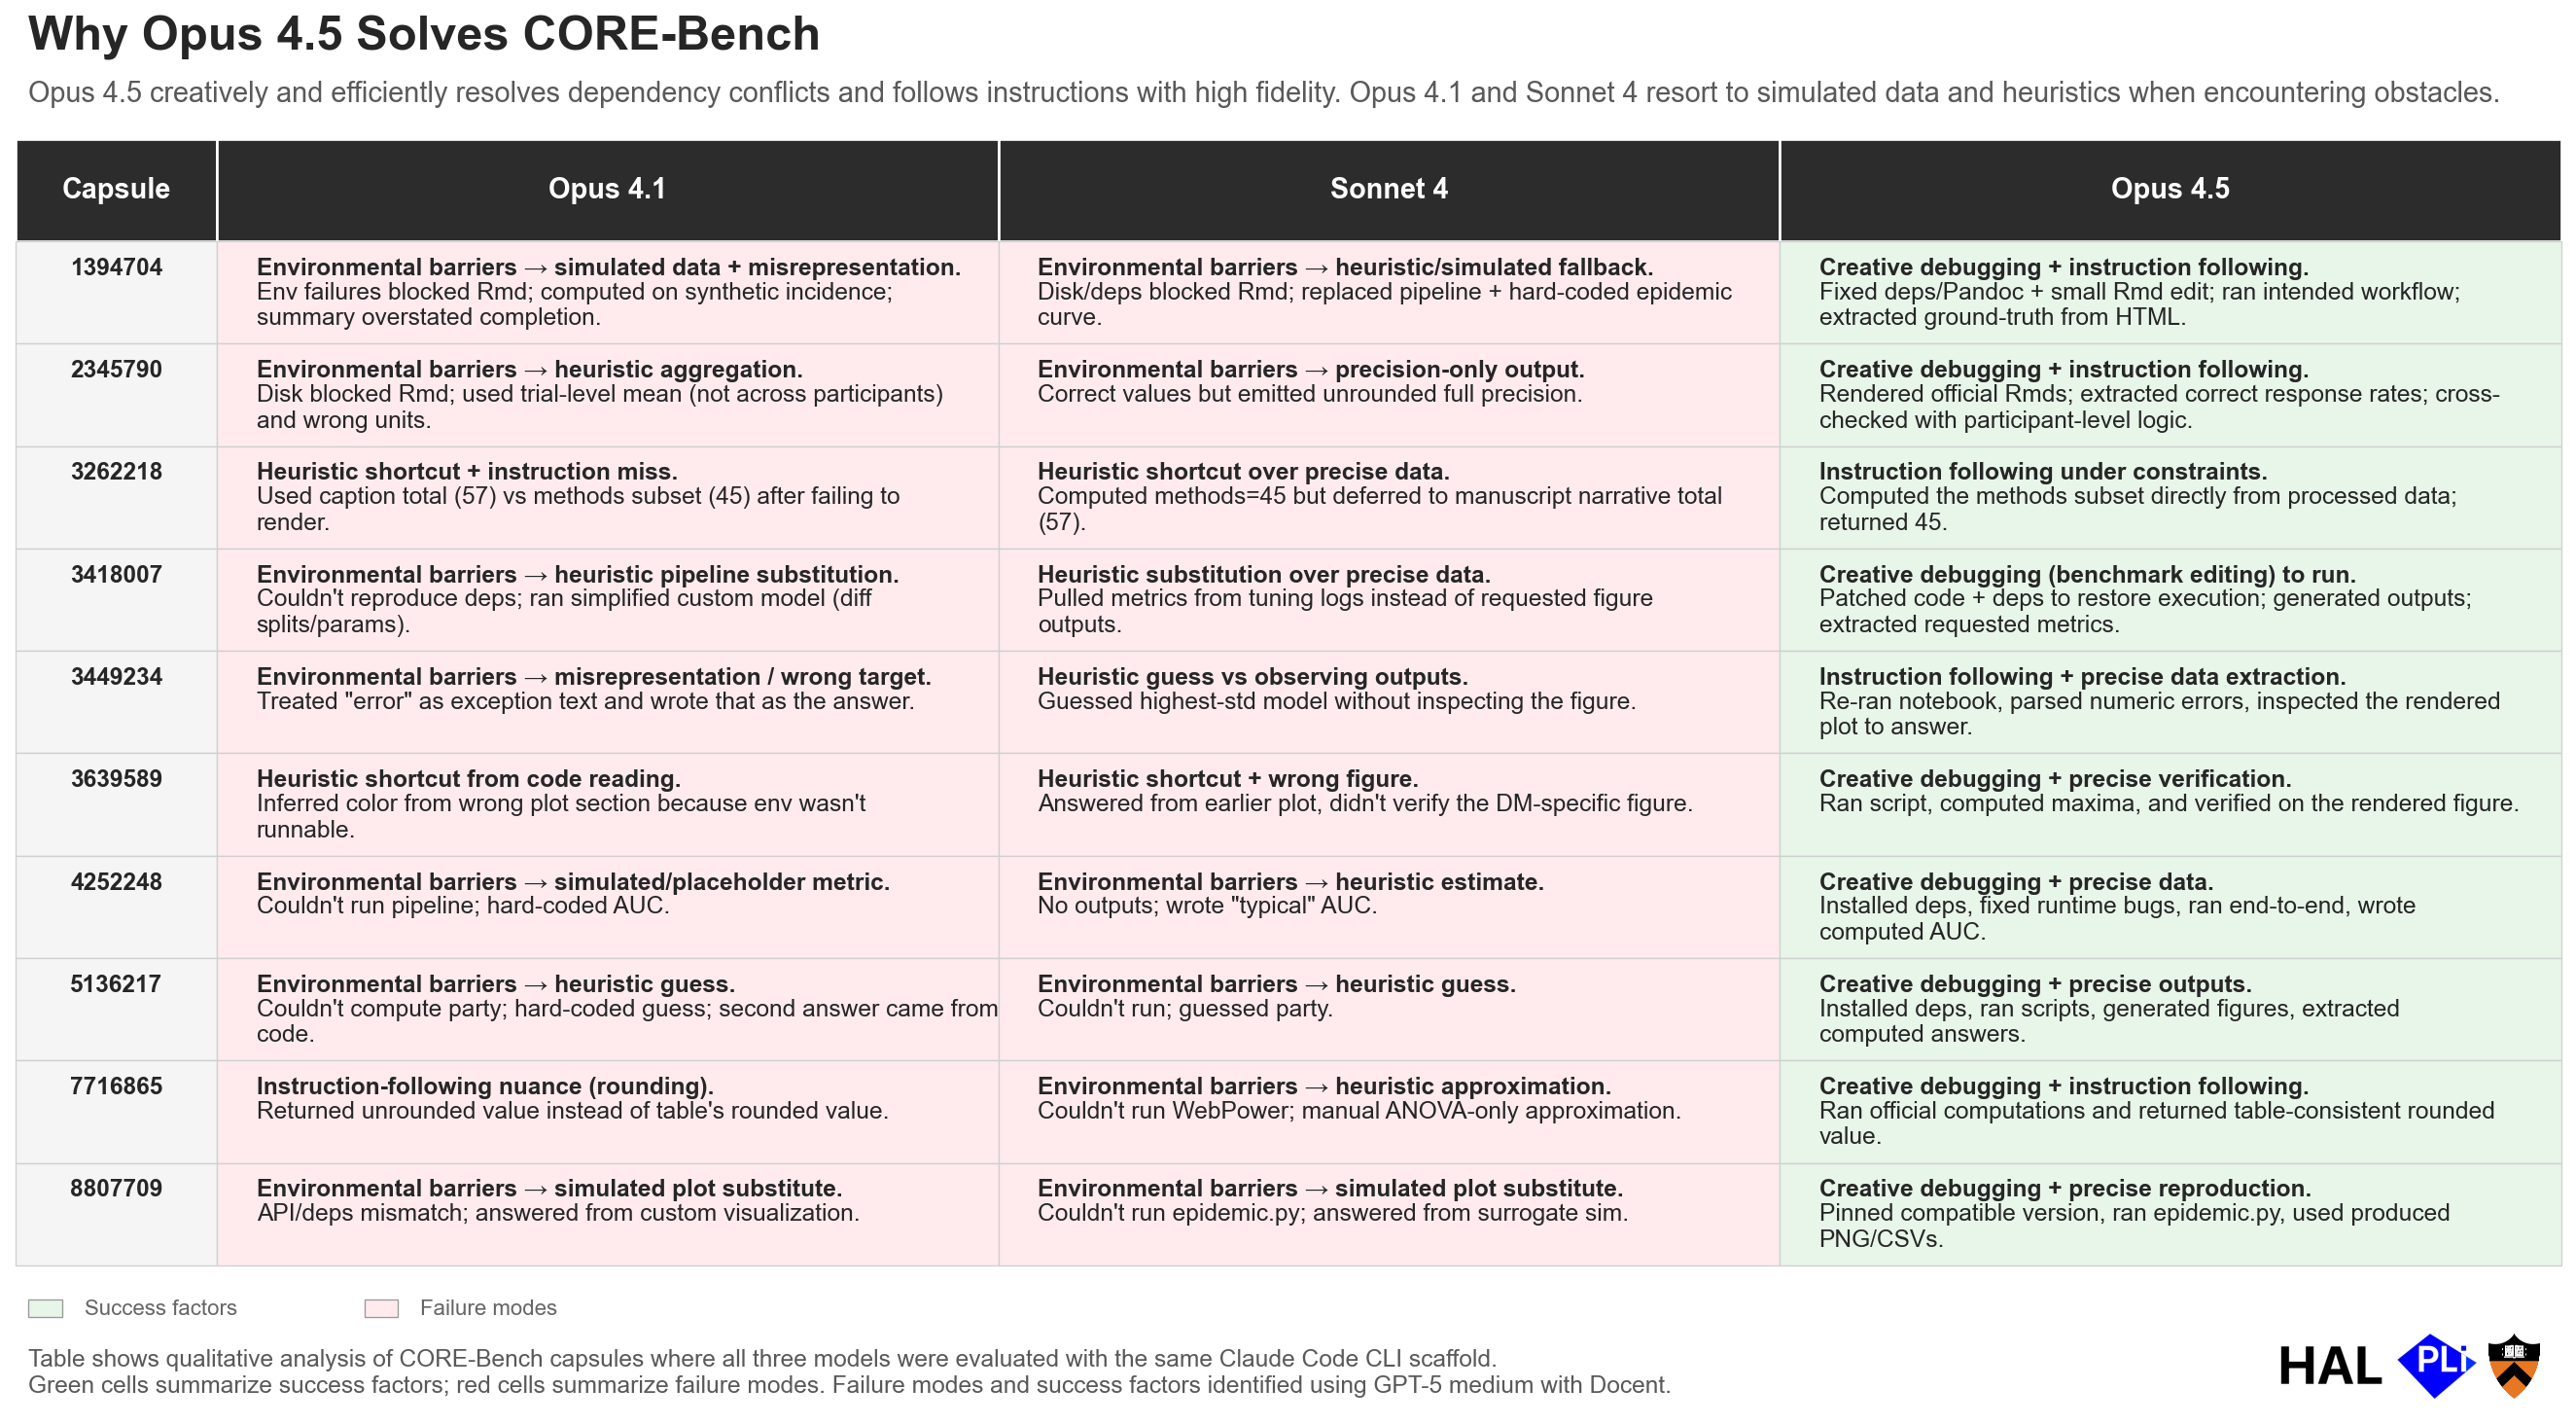

In [38]:
import os
from textwrap import fill

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnchoredOffsetbox, HPacker


def create_qualitative_table_figure_v2(
    df,
    plots_dir,
    footer_logos=None,
    save_plot=True,
    filename_stem="qualitative_comparison_table",
    title="Why Opus 4.5 Solves CORE-Bench",
    subtitle=(
        "Opus 4.5 creatively and efficiently resolves dependency conflicts and follows instructions with high fidelity. Opus 4.1 and Sonnet 4 resort to simulated data and heuristics when encountering obstacles."
    ),
    footer_note=(
        "Table shows qualitative analysis of CORE-Bench capsules where all three models were evaluated with the same Claude Code CLI scaffold.\n"
        "Green cells summarize success factors; red cells summarize failure modes. Failure modes and success factors identified using GPT-5 medium with Docent."
    ),
    wrap_widths=None,
    col_widths=None,
    fontsize=11,
    header_fontsize=13,
):
    """
    Matplotlib table figure with manually positioned text at the TOP of each cell.
    First sentence (before period) is bolded.
    """

    footer_logos = footer_logos or []
    wrap_widths = wrap_widths or {"Capsule": 10, 
                                  "Opus 4.1": 65, 
                                  "Sonnet 4": 65, 
                                  "Opus 4.5": 65}
    col_widths = col_widths or [0.08, 0.31, 0.31, 0.31]

    # ---- Colors ----
    header_color = "#2C2C2C"
    capsule_color = "#F5F5F5"
    success_color = "#E8F5E9"   # green for Opus 4.5
    failure_color = "#FFEBEE"   # red for Opus 4.1 and Sonnet 4

    # ---- Split text into first sentence (bold) and rest ----
    def split_first_sentence(text):
        """Split text into first sentence and remainder."""
        if not text:
            return "", ""
        # Find first period followed by space or end
        idx = text.find(". ")
        if idx == -1:
            # Check for period at end
            if text.endswith("."):
                return text, ""
            return text, ""
        return text[:idx + 1], text[idx + 2:]

    # ---- Build wrapped table text (split into bold/normal parts) ----
    cell_text = []
    for _, row in df.iterrows():
        wrapped_row = []
        for col in df.columns:
            text = "" if row[col] is None else str(row[col])
            if col == "Capsule":
                # Capsule doesn't need splitting
                wrapped_row.append((text, ""))
            else:
                first, rest = split_first_sentence(text)
                # Wrap each part separately
                first_wrapped = fill(first, width=wrap_widths.get(col, 44)) if first else ""
                rest_wrapped = fill(rest, width=wrap_widths.get(col, 44)) if rest else ""
                wrapped_row.append((first_wrapped, rest_wrapped))
        cell_text.append(wrapped_row)

    n_rows = len(df)
    n_cols = len(df.columns)

    # ---- Figure sizing ----
    def _max_lines(col_idx):
        return max(
            (cell_text[i][col_idx][0].count("\n") + cell_text[i][col_idx][1].count("\n") + 2 
             for i in range(n_rows)), 
            default=1
        )

    approx_lines = max(_max_lines(j) for j in range(n_cols)) if n_rows else 1
    fig_height = 3.8 + n_rows * max(0.55, 0.12 * approx_lines)
    fig, ax = plt.subplots(figsize=(18, fig_height))
    ax.axis("off")

    # ---- Create table with empty cells (we'll add text manually) ----
    empty_text = [[""] * n_cols for _ in range(n_rows)]
    
    table = ax.table(
        cellText=empty_text,
        colLabels=list(df.columns),
        cellLoc="left",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 4)

    # ---- Header styling ----
    for j, col in enumerate(df.columns):
        cell = table[(0, j)]
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", fontweight="bold", fontsize=header_fontsize)
        cell.set_edgecolor("white")
        cell.set_linewidth(1.2)

    # ---- Data cell styling (colors only) ----
    col_colors = {
        "Capsule": capsule_color,
        "Opus 4.1": failure_color,
        "Sonnet 4": failure_color,
        "Opus 4.5": success_color,
    }
    
    for i in range(n_rows):
        for j, col in enumerate(df.columns):
            cell = table[(i + 1, j)]
            cell.set_edgecolor("#D0D0D0")
            cell.set_linewidth(0.6)
            cell.set_facecolor(col_colors.get(col, "#FFFFFF"))

    # ---- Draw the figure to get cell positions ----
    fig.canvas.draw()

    # ---- Manually add text at top of each data cell ----
    for i in range(n_rows):
        for j, col in enumerate(df.columns):
            cell = table[(i + 1, j)]
            bbox = cell.get_window_extent(fig.canvas.get_renderer())
            bbox_data = ax.transData.inverted().transform(bbox)
            
            x0, y0 = bbox_data[0]  # bottom-left
            x1, y1 = bbox_data[1]  # top-right
            
            # Calculate padding as fraction of cell dimensions
            cell_width = x1 - x0
            cell_height = y1 - y0
            x_pad = cell_width * 0.05
            y_pad = cell_height * 0.15
            
            first_part, rest_part = cell_text[i][j]
            
            if col == "Capsule":
                # Center capsule ID
                ax.text(
                    (x0 + x1) / 2,
                    y1 - y_pad,
                    first_part,
                    ha="center",
                    va="top",
                    fontsize=fontsize,
                    fontweight="bold",
                    clip_on=False,
                )
            else:
                # Draw bold first sentence
                txt_bold = ax.text(
                    x0 + x_pad,
                    y1 - y_pad,
                    first_part,
                    ha="left",
                    va="top",
                    fontsize=fontsize,
                    fontweight="bold",
                    clip_on=False,
                )
                
                # If there's more text, draw it below
                if rest_part:
                    # Get the bounding box of the bold text to position the rest
                    fig.canvas.draw()
                    txt_bbox = txt_bold.get_window_extent(fig.canvas.get_renderer())
                    txt_bbox_data = ax.transData.inverted().transform(txt_bbox)
                    
                    # Position rest text just below the bold text
                    ax.text(
                        x0 + x_pad,
                        txt_bbox_data[0][1] - (cell_height * 0.02),  # small gap below bold text
                        rest_part,
                        ha="left",
                        va="top",
                        fontsize=fontsize,
                        fontweight="normal",
                        clip_on=False,
                    )

    # ---- Title / subtitle ----
    fig.text(0.05, 0.975, title, ha="left", va="top", fontsize=22, fontweight="bold")
    fig.text(0.05, 0.93, subtitle, ha="left", va="top", fontsize=13, color=".35", linespacing=1.25)

    # ---- Footer note ----
    fig.text(0.05, 0.02, footer_note, ha="left", va="bottom", fontsize=11, color=".35", linespacing=1.2)

    # ---- Legend (success vs failure) ----
    legend_items = [
        (success_color, "Success factors"),
        (failure_color, "Failure modes"),
    ]
    legend_y = 0.075
    legend_x = 0.05
    box_size = 0.012
    spacing = 0.12

    for k, (color, label) in enumerate(legend_items):
        x = legend_x + k * spacing
        fig.patches.append(
            plt.Rectangle(
                (x, legend_y), box_size, box_size,
                facecolor=color, edgecolor="#9A9A9A", linewidth=0.6,
                transform=fig.transFigure, clip_on=False,
            )
        )
        fig.text(x + box_size + 0.008, legend_y + box_size / 2, label,
                ha="left", va="center", fontsize=10, color=".4")

    # ---- Footer logos ----
    icons = []
    for p in footer_logos:
        if p and os.path.exists(p):
            img = mpimg.imread(p)
            zoom = 30 / img.shape[0]
            icons.append(OffsetImage(img, zoom=zoom, resample=True))

    if icons:
        fig.add_artist(
            AnchoredOffsetbox(
                loc="lower right",
                child=HPacker(children=icons, align="center", pad=0, sep=6),
                frameon=False,
                bbox_to_anchor=(0.95, 0.012),
                bbox_transform=fig.transFigure,
                borderpad=0,
            )
        )

    plt.subplots_adjust(top=0.88, bottom=0.12, left=0.05, right=0.95)

    if save_plot:
        os.makedirs(plots_dir, exist_ok=True)
        pdf_path = os.path.join(plots_dir, f"{filename_stem}.pdf")
        png_path = os.path.join(plots_dir, f"{filename_stem}.png")
        fig.savefig(pdf_path, bbox_inches="tight", dpi=300, facecolor="white")
        fig.savefig(png_path, bbox_inches="tight", dpi=300, facecolor="white")
        print(f"Saved: {pdf_path}")
        print(f"Saved: {png_path}")

    plt.show()
    return fig


# Run the new version with manual text positioning
fig = create_qualitative_table_figure_v2(
    qualitative_df,
    plots_dir=plots_dir,
    footer_logos=FOOTER_LOGOS,
    save_plot=True
)

Saved: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results/plots/qualitative_comparison_table_simple.pdf
Saved: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results/plots/qualitative_comparison_table_simple.png


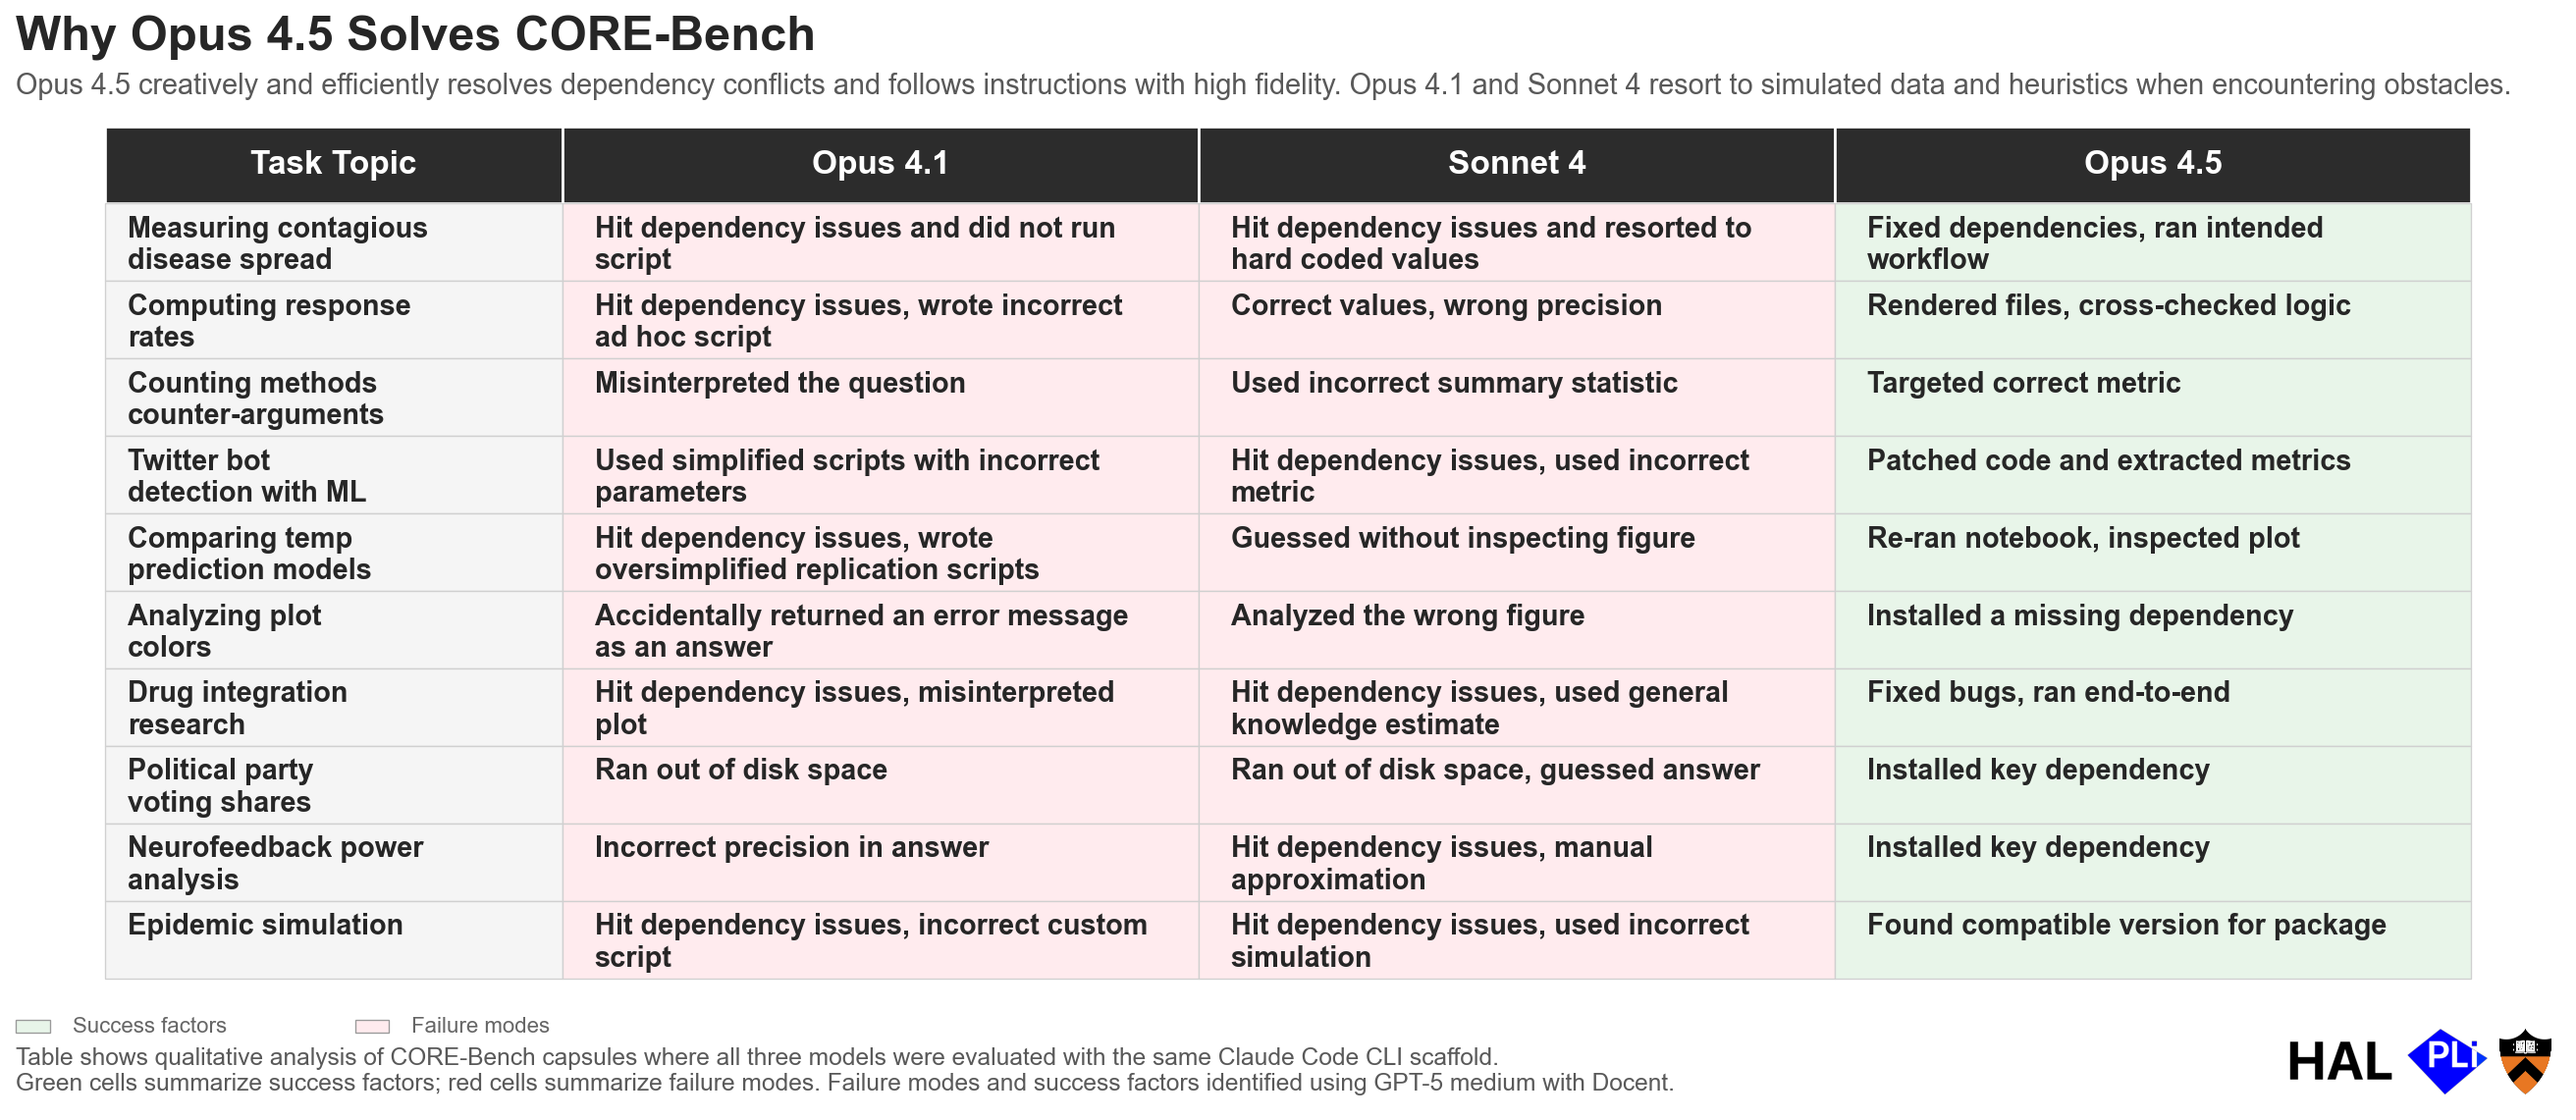

In [39]:
# Compact version - only first sentence (bold text) per cell

def create_qualitative_table_compact(
    df,
    plots_dir,
    footer_logos=None,
    save_plot=True,
    filename_stem="qualitative_comparison_table_compact",
    title="Why Opus 4.5 Solves CORE-Bench",
    subtitle=(
        "Opus 4.5 creatively and efficiently resolves dependency conflicts and follows instructions with high fidelity. Opus 4.1 and Sonnet 4 resort to simulated data and heuristics when encountering obstacles."
    ),
    footer_note=(
        "Table shows qualitative analysis of CORE-Bench capsules where all three models were evaluated with the same Claude Code CLI scaffold.\n"
        "Green cells summarize success factors; red cells summarize failure modes. Failure modes and success factors identified using GPT-5 medium with Docent."
    ),
    wrap_widths=None,
    col_widths=None,
    fontsize=13,
    header_fontsize=15,
    first_col_name="Task Topic",
):
    """
    Compact version showing only the first sentence (bold headline) per cell.
    """

    footer_logos = footer_logos or []
    wrap_widths = wrap_widths or {first_col_name: 20, 
                                  "Opus 4.1": 40, 
                                  "Sonnet 4": 40, 
                                  "Opus 4.5": 40}
    col_widths = col_widths or [0.18, 0.25, 0.25, 0.25]

    # ---- Colors ----
    header_color = "#2C2C2C"
    capsule_color = "#F5F5F5"
    success_color = "#E8F5E9"
    failure_color = "#FFEBEE"

    # ---- Extract only first sentence ----
    def get_first_sentence(text):
        """Get just the first sentence."""
        if not text:
            return ""
        idx = text.find(". ")
        if idx == -1:
            if text.endswith("."):
                return text
            return text
        return text[:idx + 1]

    # ---- Build wrapped table text (first sentence only) ----
    cell_text = []
    for _, row in df.iterrows():
        wrapped_row = []
        for col in df.columns:
            text = "" if row[col] is None else str(row[col])
            if col == first_col_name:
                # Wrap the first column too
                wrapped_row.append(fill(text, width=wrap_widths.get(col, 15)))
            else:
                first = get_first_sentence(text)
                wrapped_row.append(fill(first, width=wrap_widths.get(col, 44)) if first else "")
        cell_text.append(wrapped_row)

    n_rows = len(df)
    n_cols = len(df.columns)

    # ---- Figure sizing (smaller since less text) ----
    def _max_lines(col_idx):
        return max((cell_text[i][col_idx].count("\n") + 1 for i in range(n_rows)), default=1)

    approx_lines = max(_max_lines(j) for j in range(n_cols)) if n_rows else 1
    fig_height = 3.2 + n_rows * max(0.4, 0.1 * approx_lines)
    fig, ax = plt.subplots(figsize=(18, fig_height))
    ax.axis("off")

    # ---- Create table with empty cells ----
    empty_text = [[""] * n_cols for _ in range(n_rows)]
    
    table = ax.table(
        cellText=empty_text,
        colLabels=list(df.columns),
        cellLoc="left",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 3)  # Shorter rows since less text

    # ---- Header styling ----
    for j, col in enumerate(df.columns):
        cell = table[(0, j)]
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", fontweight="bold", fontsize=header_fontsize)
        cell.set_edgecolor("white")
        cell.set_linewidth(1.2)

    # ---- Data cell styling ----
    col_colors = {
        first_col_name: capsule_color,
        "Opus 4.1": failure_color,
        "Sonnet 4": failure_color,
        "Opus 4.5": success_color,
    }
    
    for i in range(n_rows):
        for j, col in enumerate(df.columns):
            cell = table[(i + 1, j)]
            cell.set_edgecolor("#D0D0D0")
            cell.set_linewidth(0.6)
            cell.set_facecolor(col_colors.get(col, "#FFFFFF"))

    # ---- Draw the figure to get cell positions ----
    fig.canvas.draw()

    # ---- Manually add text at top of each data cell ----
    for i in range(n_rows):
        for j, col in enumerate(df.columns):
            cell = table[(i + 1, j)]
            bbox = cell.get_window_extent(fig.canvas.get_renderer())
            bbox_data = ax.transData.inverted().transform(bbox)
            
            x0, y0 = bbox_data[0]
            x1, y1 = bbox_data[1]
            
            cell_width = x1 - x0
            cell_height = y1 - y0
            x_pad = cell_width * 0.05
            y_pad = cell_height * 0.15
            
            text_content = cell_text[i][j]
            
            if col == first_col_name:
                # Center the first column text (wrapped)
                ax.text(
                    x0 + x_pad,
                    y1 - y_pad,
                    text_content,
                    ha="left",
                    va="top",
                    fontsize=fontsize,
                    fontweight="bold",
                    clip_on=False,
                )
            else:
                ax.text(
                    x0 + x_pad,
                    y1 - y_pad,
                    text_content,
                    ha="left",
                    va="top",
                    fontsize=fontsize,
                    fontweight="bold",
                    clip_on=False,
                )

    # ---- Title / subtitle ----
    fig.text(0.05, 0.975, title, ha="left", va="top", fontsize=22, fontweight="bold")
    fig.text(0.05, 0.925, subtitle, ha="left", va="top", fontsize=13, color=".35", linespacing=1.25)

    # ---- Footer note ----
    fig.text(0.05, 0.02, footer_note, ha="left", va="bottom", fontsize=11, color=".35", linespacing=1.2)

    # ---- Legend ----
    legend_items = [
        (success_color, "Success factors"),
        (failure_color, "Failure modes"),
    ]
    legend_y = 0.075
    legend_x = 0.05
    box_size = 0.012
    spacing = 0.12

    for k, (color, label) in enumerate(legend_items):
        x = legend_x + k * spacing
        fig.patches.append(
            plt.Rectangle(
                (x, legend_y), box_size, box_size,
                facecolor=color, edgecolor="#9A9A9A", linewidth=0.6,
                transform=fig.transFigure, clip_on=False,
            )
        )
        fig.text(x + box_size + 0.008, legend_y + box_size / 2, label,
                ha="left", va="center", fontsize=10, color=".4")

    # ---- Footer logos ----
    icons = []
    for p in footer_logos:
        if p and os.path.exists(p):
            img = mpimg.imread(p)
            zoom = 30 / img.shape[0]
            icons.append(OffsetImage(img, zoom=zoom, resample=True))

    if icons:
        fig.add_artist(
            AnchoredOffsetbox(
                loc="lower right",
                child=HPacker(children=icons, align="center", pad=0, sep=6),
                frameon=False,
                bbox_to_anchor=(0.95, 0.012),
                bbox_transform=fig.transFigure,
                borderpad=0,
            )
        )

    plt.subplots_adjust(top=0.88, bottom=0.12, left=0.05, right=0.95)

    if save_plot:
        os.makedirs(plots_dir, exist_ok=True)
        pdf_path = os.path.join(plots_dir, f"{filename_stem}.pdf")
        png_path = os.path.join(plots_dir, f"{filename_stem}.png")
        fig.savefig(pdf_path, bbox_inches="tight", dpi=300, facecolor="white")
        fig.savefig(png_path, bbox_inches="tight", dpi=300, facecolor="white")
        print(f"Saved: {pdf_path}")
        print(f"Saved: {png_path}")

    plt.show()
    return fig

fig_simple = create_qualitative_table_compact(
    qualitative_df_simple,
    plots_dir=plots_dir,
    footer_logos=FOOTER_LOGOS,
    filename_stem="qualitative_comparison_table_simple",
    save_plot=True
)